# AI-Powered Vehicle Insurance Fraud Detection
**Dataset:** `fraud_oracle.csv` — 15,420 rows × 33 columns  
**Target:** `FraudFound_P` (0 = Not Fraud, 1 = Fraud)  
**Pipeline:** Structured feature encoding → Isolation Forest (anomaly score) → XGBoost/LightGBM → Groq LLaMA 3 summaries → Email

---
### Sections
**EDA**
0. Setup & Imports
1. Data Loading & Initial Inspection
2. Target Distribution
3. Numeric Feature Analysis
4. Categorical Feature Analysis
5. Ordinal Feature Analysis
6. Bivariate Analysis (features vs Fraud)
7. Correlation Analysis
8. EDA Summary & Final Feature List

**Modeling**
9. Preprocessing Pipeline
10. Train / Val / Test Split + SMOTE
11. Baseline — Logistic Regression
12. Isolation Forest (anomaly score feature)
13. XGBoost
14. LightGBM
15. Model Comparison
16. Threshold Tuning
17. SHAP Explainability
18. Final Test Set Evaluation
19. Save Models & Artifacts

---
## Section 0 — Setup & Imports

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import pointbiserialr, chi2_contingency

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='Set2')

print('Libraries imported successfully.')

Libraries imported successfully.


---
## Section 1 — Data Loading & Initial Inspection

In [156]:
DATA_PATH = r'C:\Users\RadheRadhe\Desktop\Self project\DS\project work\fraud_oracle.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}  →  {df.shape[0]:,} rows × {df.shape[1]} columns')

Shape: (15420, 33)  →  15,420 rows × 33 columns


In [157]:
# Column names and dtypes
print('Columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col:<35} dtype: {df[col].dtype}')

Columns:
   1. Month                               dtype: str
   2. WeekOfMonth                         dtype: int64
   3. DayOfWeek                           dtype: str
   4. Make                                dtype: str
   5. AccidentArea                        dtype: str
   6. DayOfWeekClaimed                    dtype: str
   7. MonthClaimed                        dtype: str
   8. WeekOfMonthClaimed                  dtype: int64
   9. Sex                                 dtype: str
  10. MaritalStatus                       dtype: str
  11. Age                                 dtype: int64
  12. Fault                               dtype: str
  13. PolicyType                          dtype: str
  14. VehicleCategory                     dtype: str
  15. VehiclePrice                        dtype: str
  16. FraudFound_P                        dtype: int64
  17. PolicyNumber                        dtype: int64
  18. RepNumber                           dtype: int64
  19. Deductible         

In [158]:
# Missing values check
total_missing = df.isnull().sum().sum()
print(f'Total missing values: {total_missing}')
if total_missing == 0:
    print('No missing values — no imputation needed.')

Total missing values: 0
No missing values — no imputation needed.


In [159]:
# First 3 rows
df.head(3)

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision


In [160]:
# Drop ID-like columns — no predictive value
df.drop(columns=['PolicyNumber', 'RepNumber'], inplace=True)
print('Dropped: PolicyNumber, RepNumber')

# Fix Age = 0 (placeholder for unknown) → replace with median
age_median = df[df['Age'] > 0]['Age'].median()
df.loc[df['Age'] == 0, 'Age'] = age_median
print(f'Age = 0 rows replaced with median age: {age_median}')

# Fix '0' placeholder in DayOfWeekClaimed and MonthClaimed
df['DayOfWeekClaimed'] = df['DayOfWeekClaimed'].replace('0', 'Unknown')
df['MonthClaimed']     = df['MonthClaimed'].replace('0', 'Unknown')
print(f'DayOfWeekClaimed zeros replaced: now {df["DayOfWeekClaimed"].nunique()} unique values')
print(f'MonthClaimed zeros replaced    : now {df["MonthClaimed"].nunique()} unique values')
print(f'Remaining columns: {df.shape[1]}')

Dropped: PolicyNumber, RepNumber
Age = 0 rows replaced with median age: 39.0
DayOfWeekClaimed zeros replaced: now 8 unique values
MonthClaimed zeros replaced    : now 13 unique values
Remaining columns: 31


---
## Section 2 — Target Distribution

In [161]:
label_counts = df['FraudFound_P'].value_counts()
label_pct    = df['FraudFound_P'].value_counts(normalize=True) * 100

print('FraudFound_P distribution:')
print(f'  0 (Not Fraud) : {label_counts[0]:,}  ({label_pct[0]:.1f}%)')
print(f'  1 (Fraud)      : {label_counts[1]:,}  ({label_pct[1]:.1f}%)')
print(f'  Imbalance ratio: {label_counts[0]/label_counts[1]:.1f} : 1')
print(f'\n  Severe imbalance → SMOTE required')

FraudFound_P distribution:
  0 (Not Fraud) : 14,497  (94.0%)
  1 (Fraud)      : 923  (6.0%)
  Imbalance ratio: 15.7 : 1

  Severe imbalance → SMOTE required


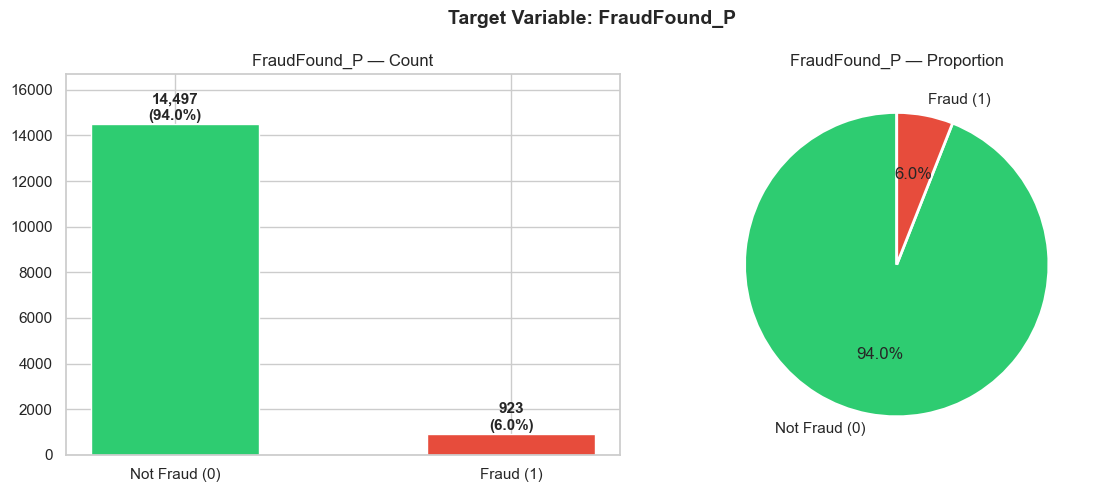

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], label_counts, color=colors, edgecolor='white', width=0.5)
for bar, count, pct in zip(bars, label_counts, label_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('FraudFound_P — Count')
axes[0].set_ylim(0, max(label_counts) * 1.15)

axes[1].pie(label_counts, labels=['Not Fraud (0)', 'Fraud (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('FraudFound_P — Proportion')

plt.suptitle('Target Variable: FraudFound_P', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Numeric Feature Analysis

In [163]:
# True numeric columns (continuous/discrete integers)
NUMERIC_COLS = ['Age', 'DriverRating', 'WeekOfMonth', 'WeekOfMonthClaimed', 'Year']
# Note: Deductible moved to ordinal (only 4 values: 300,400,500,700)

print('Numeric feature stats:')
df[NUMERIC_COLS].describe().round(2)

Numeric feature stats:


,Age,DriverRating,WeekOfMonth,WeekOfMonthClaimed,Year
count,15420.00,15420.00,15420.00,15420.00,15420.00
mean,40.67,2.49,2.79,2.69,1994.87
std,12.18,1.12,1.29,1.26,0.80
min,16.00,1.00,1.00,1.00,1994.00
25%,31.00,1.00,2.00,2.00,1994.00
50%,39.00,2.00,3.00,3.00,1995.00
75%,48.00,3.00,4.00,4.00,1996.00
max,80.00,4.00,5.00,5.00,1996.00


In [164]:
# Investigate anomalies found in stats
print(f'Age = 0 rows: {(df["Age"] == 0).sum()}')
print(f'Deductible unique values: {sorted(df["Deductible"].unique())}')
print(f'DriverRating unique values: {sorted(df["DriverRating"].unique())}')
print(f'Year unique values: {sorted(df["Year"].unique())}')
print(f'WeekOfMonth unique values: {sorted(df["WeekOfMonth"].unique())}')
print(f'DayOfWeekClaimed unique values: {df["DayOfWeekClaimed"].unique().tolist()}')
print(f'MonthClaimed unique values: {df["MonthClaimed"].unique().tolist()}')

Age = 0 rows: 0
Deductible unique values: [np.int64(300), np.int64(400), np.int64(500), np.int64(700)]
DriverRating unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Year unique values: [np.int64(1994), np.int64(1995), np.int64(1996)]
WeekOfMonth unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
DayOfWeekClaimed unique values: ['Tuesday', 'Monday', 'Thursday', 'Friday', 'Wednesday', 'Saturday', 'Sunday', 'Unknown']
MonthClaimed unique values: ['Jan', 'Nov', 'Jul', 'Feb', 'Mar', 'Dec', 'Apr', 'Aug', 'May', 'Jun', 'Sep', 'Oct', 'Unknown']


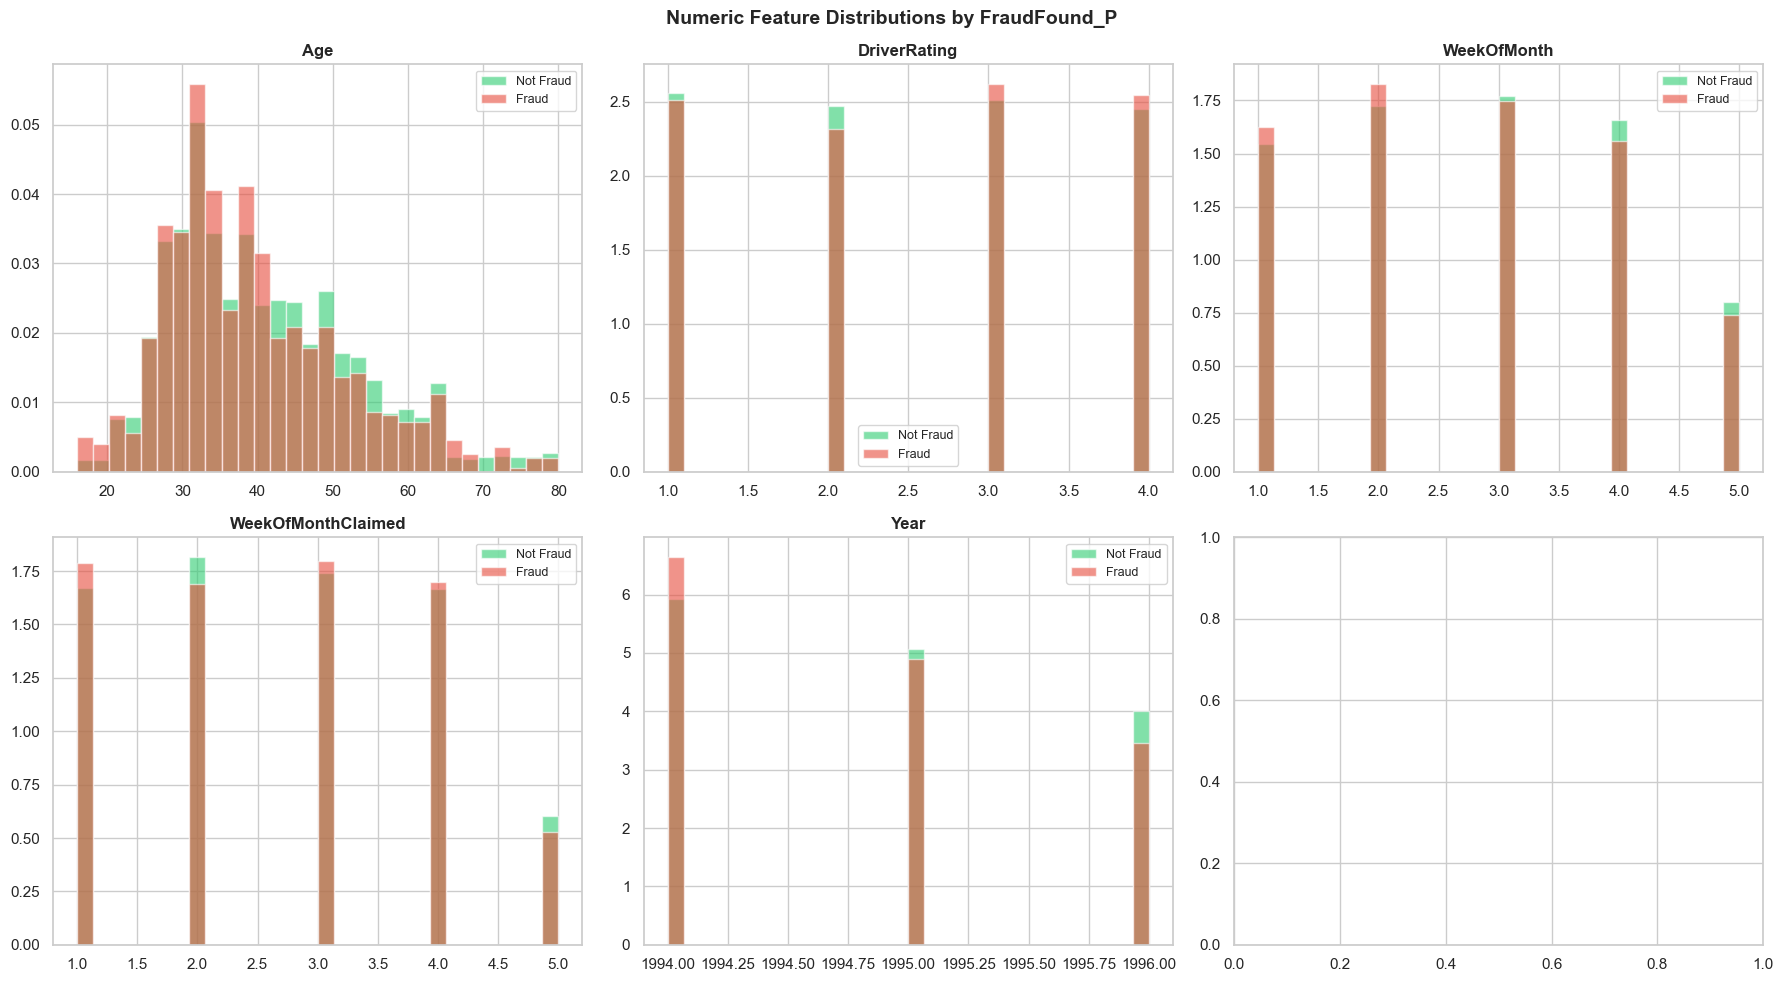

In [165]:
# Distributions split by FraudFound_P
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    for label_val, color, name in [(0, '#2ecc71', 'Not Fraud'), (1, '#e74c3c', 'Fraud')]:
        data = df[df['FraudFound_P'] == label_val][col]
        ax.hist(data, bins=30, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Numeric Feature Distributions by FraudFound_P', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [166]:
# Point-biserial correlation: numeric features vs FraudFound_P
print('Point-biserial correlation with FraudFound_P:')
print('-' * 55)
for col in NUMERIC_COLS:
    corr, pval = pointbiserialr(df['FraudFound_P'], df[col])
    sig = '✓' if pval < 0.05 else '✗'
    print(f'  {sig} {col:<25} r = {corr:+.4f}  (p={pval:.4f})')

Point-biserial correlation with FraudFound_P:
-------------------------------------------------------
  ✓ Age                       r = -0.0226  (p=0.0051)
  ✗ DriverRating              r = +0.0073  (p=0.3669)
  ✗ WeekOfMonth               r = -0.0119  (p=0.1408)
  ✗ WeekOfMonthClaimed        r = -0.0058  (p=0.4744)
  ✓ Year                      r = -0.0248  (p=0.0021)


---
## Section 4 — Categorical Feature Analysis
Nominal categoricals — no natural order → OHE

In [167]:
NOMINAL_COLS = ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
                'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
                'VehicleCategory', 'PoliceReportFiled', 'WitnessPresent',
                'AgentType', 'BasePolicy']

print('Nominal categorical unique value counts:')
for col in NOMINAL_COLS:
    n = df[col].nunique()
    top = df[col].value_counts().head(3).to_dict()
    print(f'  {col:<28} → {n:>3} unique | {top}')

Nominal categorical unique value counts:
  Month                        →  12 unique | {'Jan': 1411, 'May': 1367, 'Mar': 1360}
  DayOfWeek                    →   7 unique | {'Monday': 2616, 'Friday': 2445, 'Tuesday': 2300}
  Make                         →  19 unique | {'Pontiac': 3837, 'Toyota': 3121, 'Honda': 2801}
  AccidentArea                 →   2 unique | {'Urban': 13822, 'Rural': 1598}
  DayOfWeekClaimed             →   8 unique | {'Monday': 3757, 'Tuesday': 3375, 'Wednesday': 2951}
  MonthClaimed                 →  13 unique | {'Jan': 1446, 'May': 1411, 'Mar': 1348}
  Sex                          →   2 unique | {'Male': 13000, 'Female': 2420}
  MaritalStatus                →   4 unique | {'Married': 10625, 'Single': 4684, 'Divorced': 76}
  Fault                        →   2 unique | {'Policy Holder': 11230, 'Third Party': 4190}
  PolicyType                   →   9 unique | {'Sedan - Collision': 5584, 'Sedan - Liability': 4987, 'Sedan - All Perils': 4087}
  VehicleCategory      

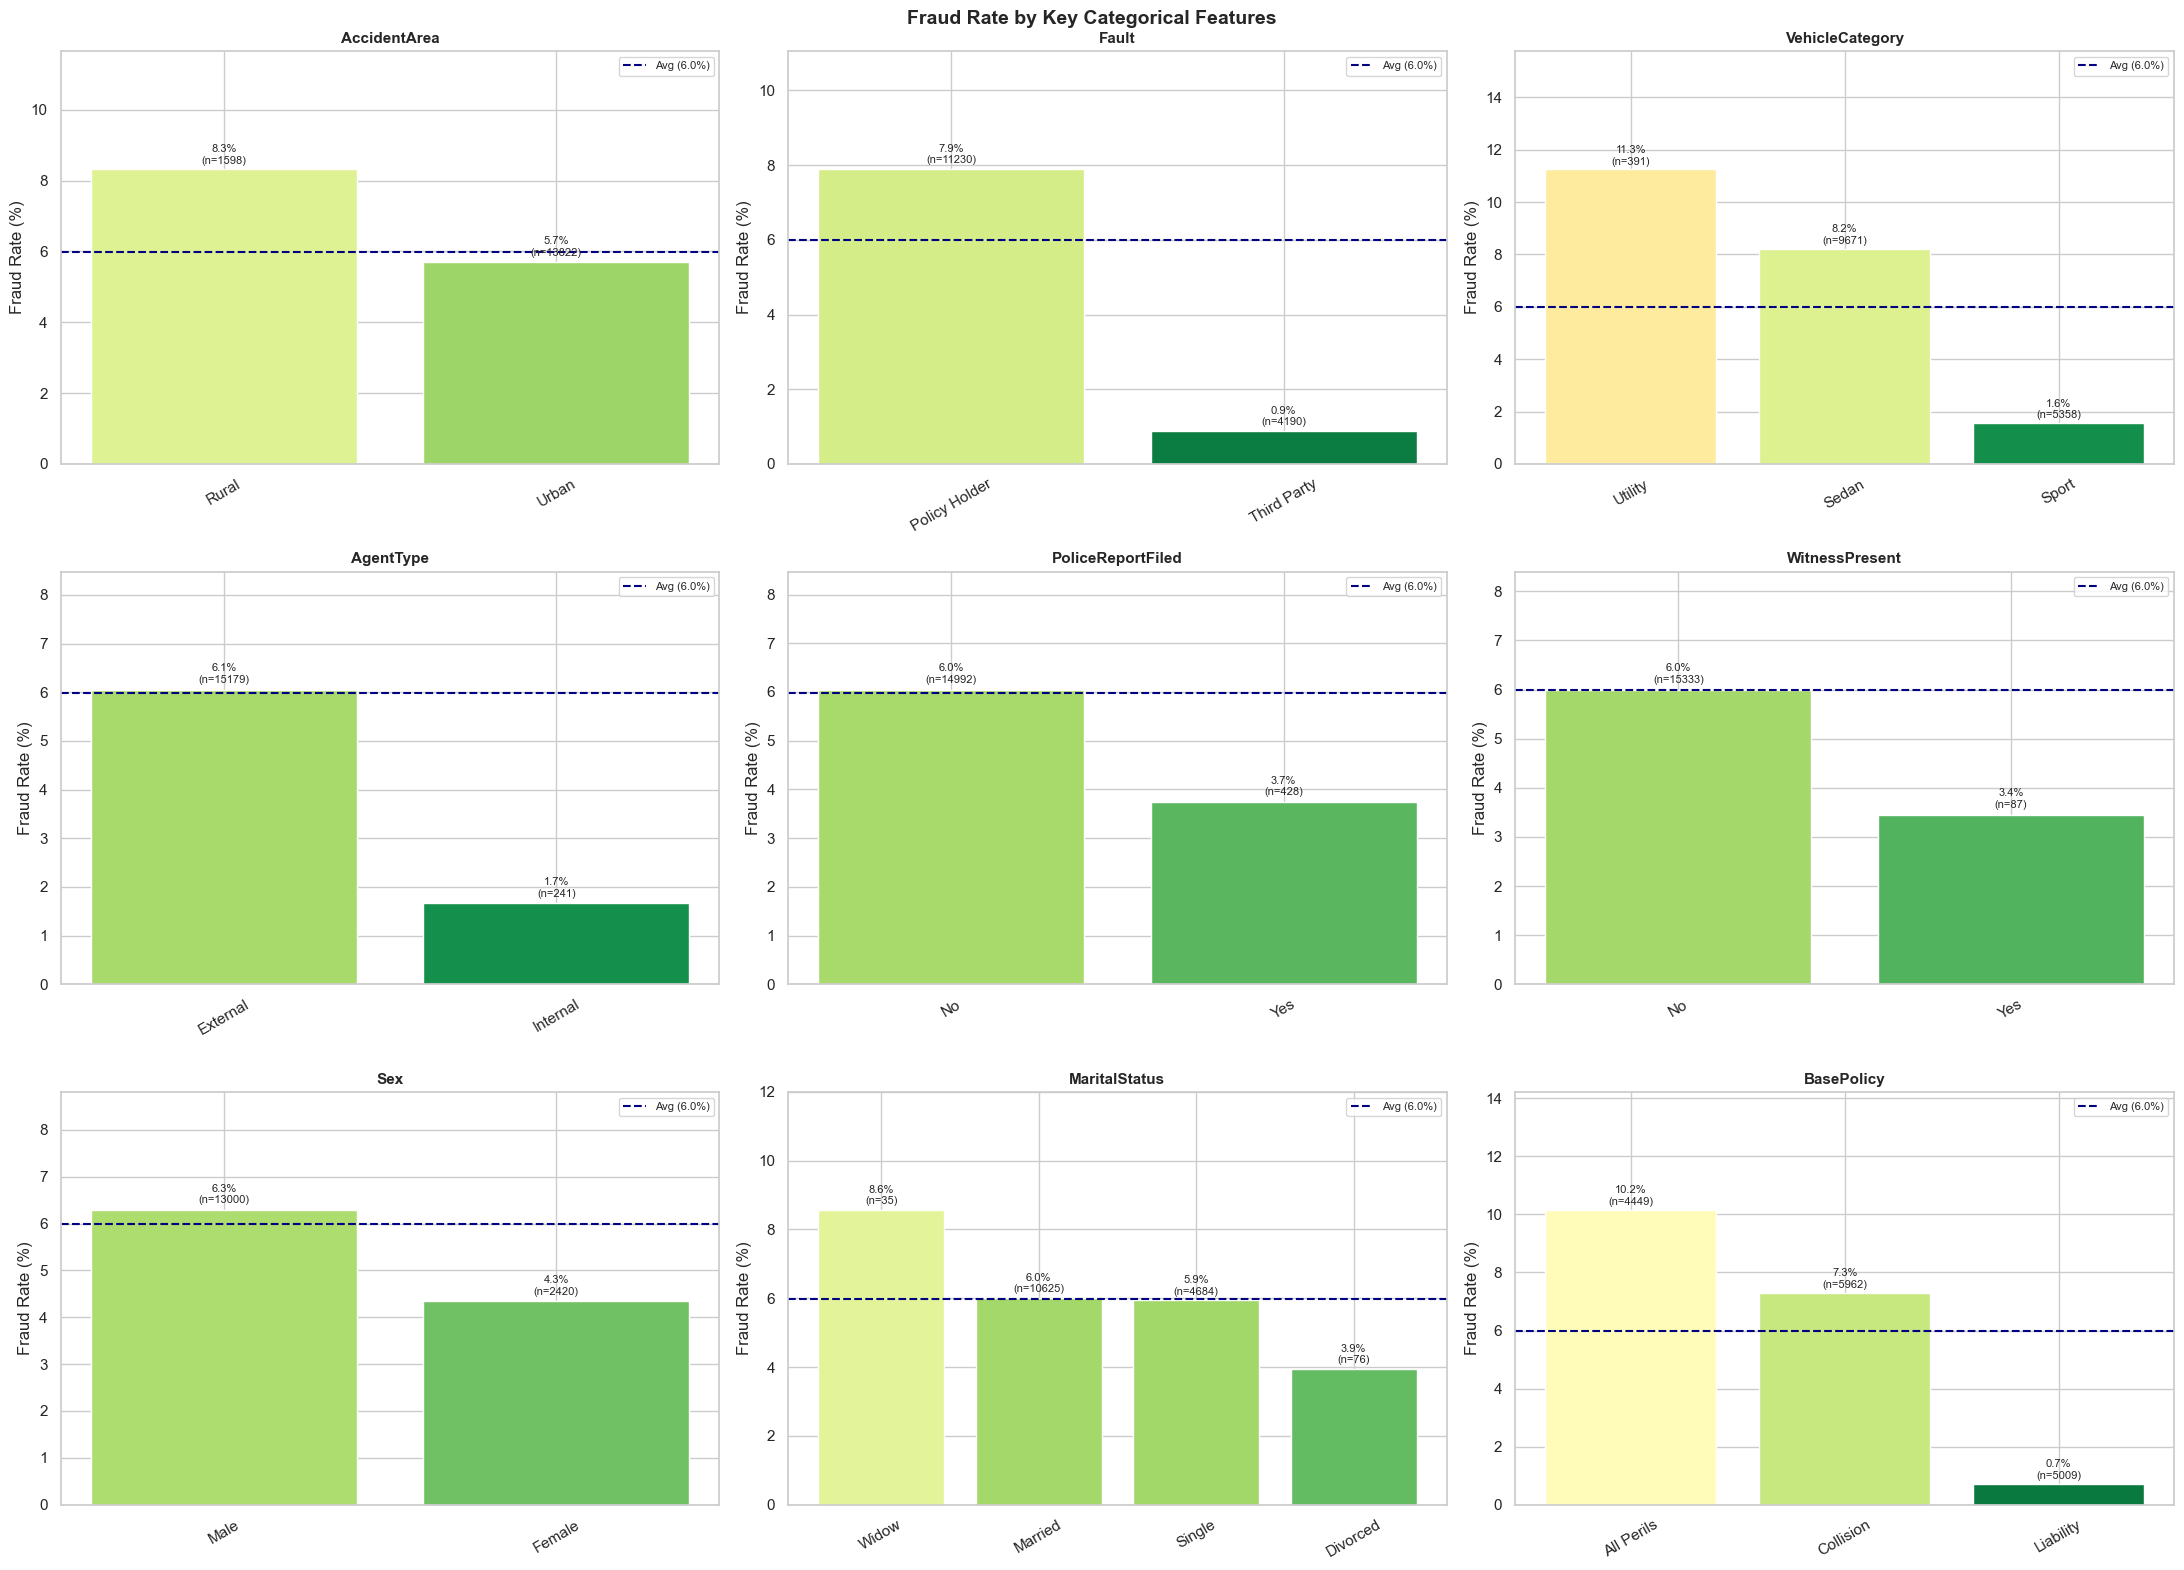

In [168]:
# Fraud rate per key categorical — which categories are high-risk?
KEY_CATS = ['AccidentArea', 'Fault', 'VehicleCategory', 'AgentType',
            'PoliceReportFiled', 'WitnessPresent', 'Sex', 'MaritalStatus', 'BasePolicy']

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
axes = axes.flatten()
overall_rate = df['FraudFound_P'].mean() * 100

for i, col in enumerate(KEY_CATS):
    ax = axes[i]
    fraud_rate = df.groupby(col)['FraudFound_P'].mean().sort_values(ascending=False) * 100
    count = df.groupby(col)['FraudFound_P'].count().reindex(fraud_rate.index)
    bars = ax.bar(fraud_rate.index.astype(str), fraud_rate.values,
                  color=plt.cm.RdYlGn_r(fraud_rate.values / 20), edgecolor='white')
    for bar, val, cnt in zip(bars, fraud_rate.values, count.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%\n(n={cnt})', ha='center', va='bottom', fontsize=8)
    ax.axhline(y=overall_rate, color='navy', linestyle='--', linewidth=1.5,
               label=f'Avg ({overall_rate:.1f}%)')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_ylim(0, max(fraud_rate.values) * 1.4)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.suptitle('Fraud Rate by Key Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5 — Ordinal Feature Analysis
Ordinal strings — have a natural order → OrdinalEncoder with defined order

In [171]:
# Check unique values for each ordinal column to define encoding order
ORDINAL_COLS = ['VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim',
                'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
                'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars']

for col in ORDINAL_COLS:
    print(f'{col}: {sorted(df[col].unique().tolist())}')

VehiclePrice: ['20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000', 'less than 20000', 'more than 69000']
Days_Policy_Accident: ['1 to 7', '15 to 30', '8 to 15', 'more than 30', 'none']
Days_Policy_Claim: ['15 to 30', '8 to 15', 'more than 30', 'none']
PastNumberOfClaims: ['1', '2 to 4', 'more than 4', 'none']
AgeOfVehicle: ['2 years', '3 years', '4 years', '5 years', '6 years', '7 years', 'more than 7', 'new']
AgeOfPolicyHolder: ['16 to 17', '18 to 20', '21 to 25', '26 to 30', '31 to 35', '36 to 40', '41 to 50', '51 to 65', 'over 65']
NumberOfSuppliments: ['1 to 2', '3 to 5', 'more than 5', 'none']
AddressChange_Claim: ['1 year', '2 to 3 years', '4 to 8 years', 'no change', 'under 6 months']
NumberOfCars: ['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']


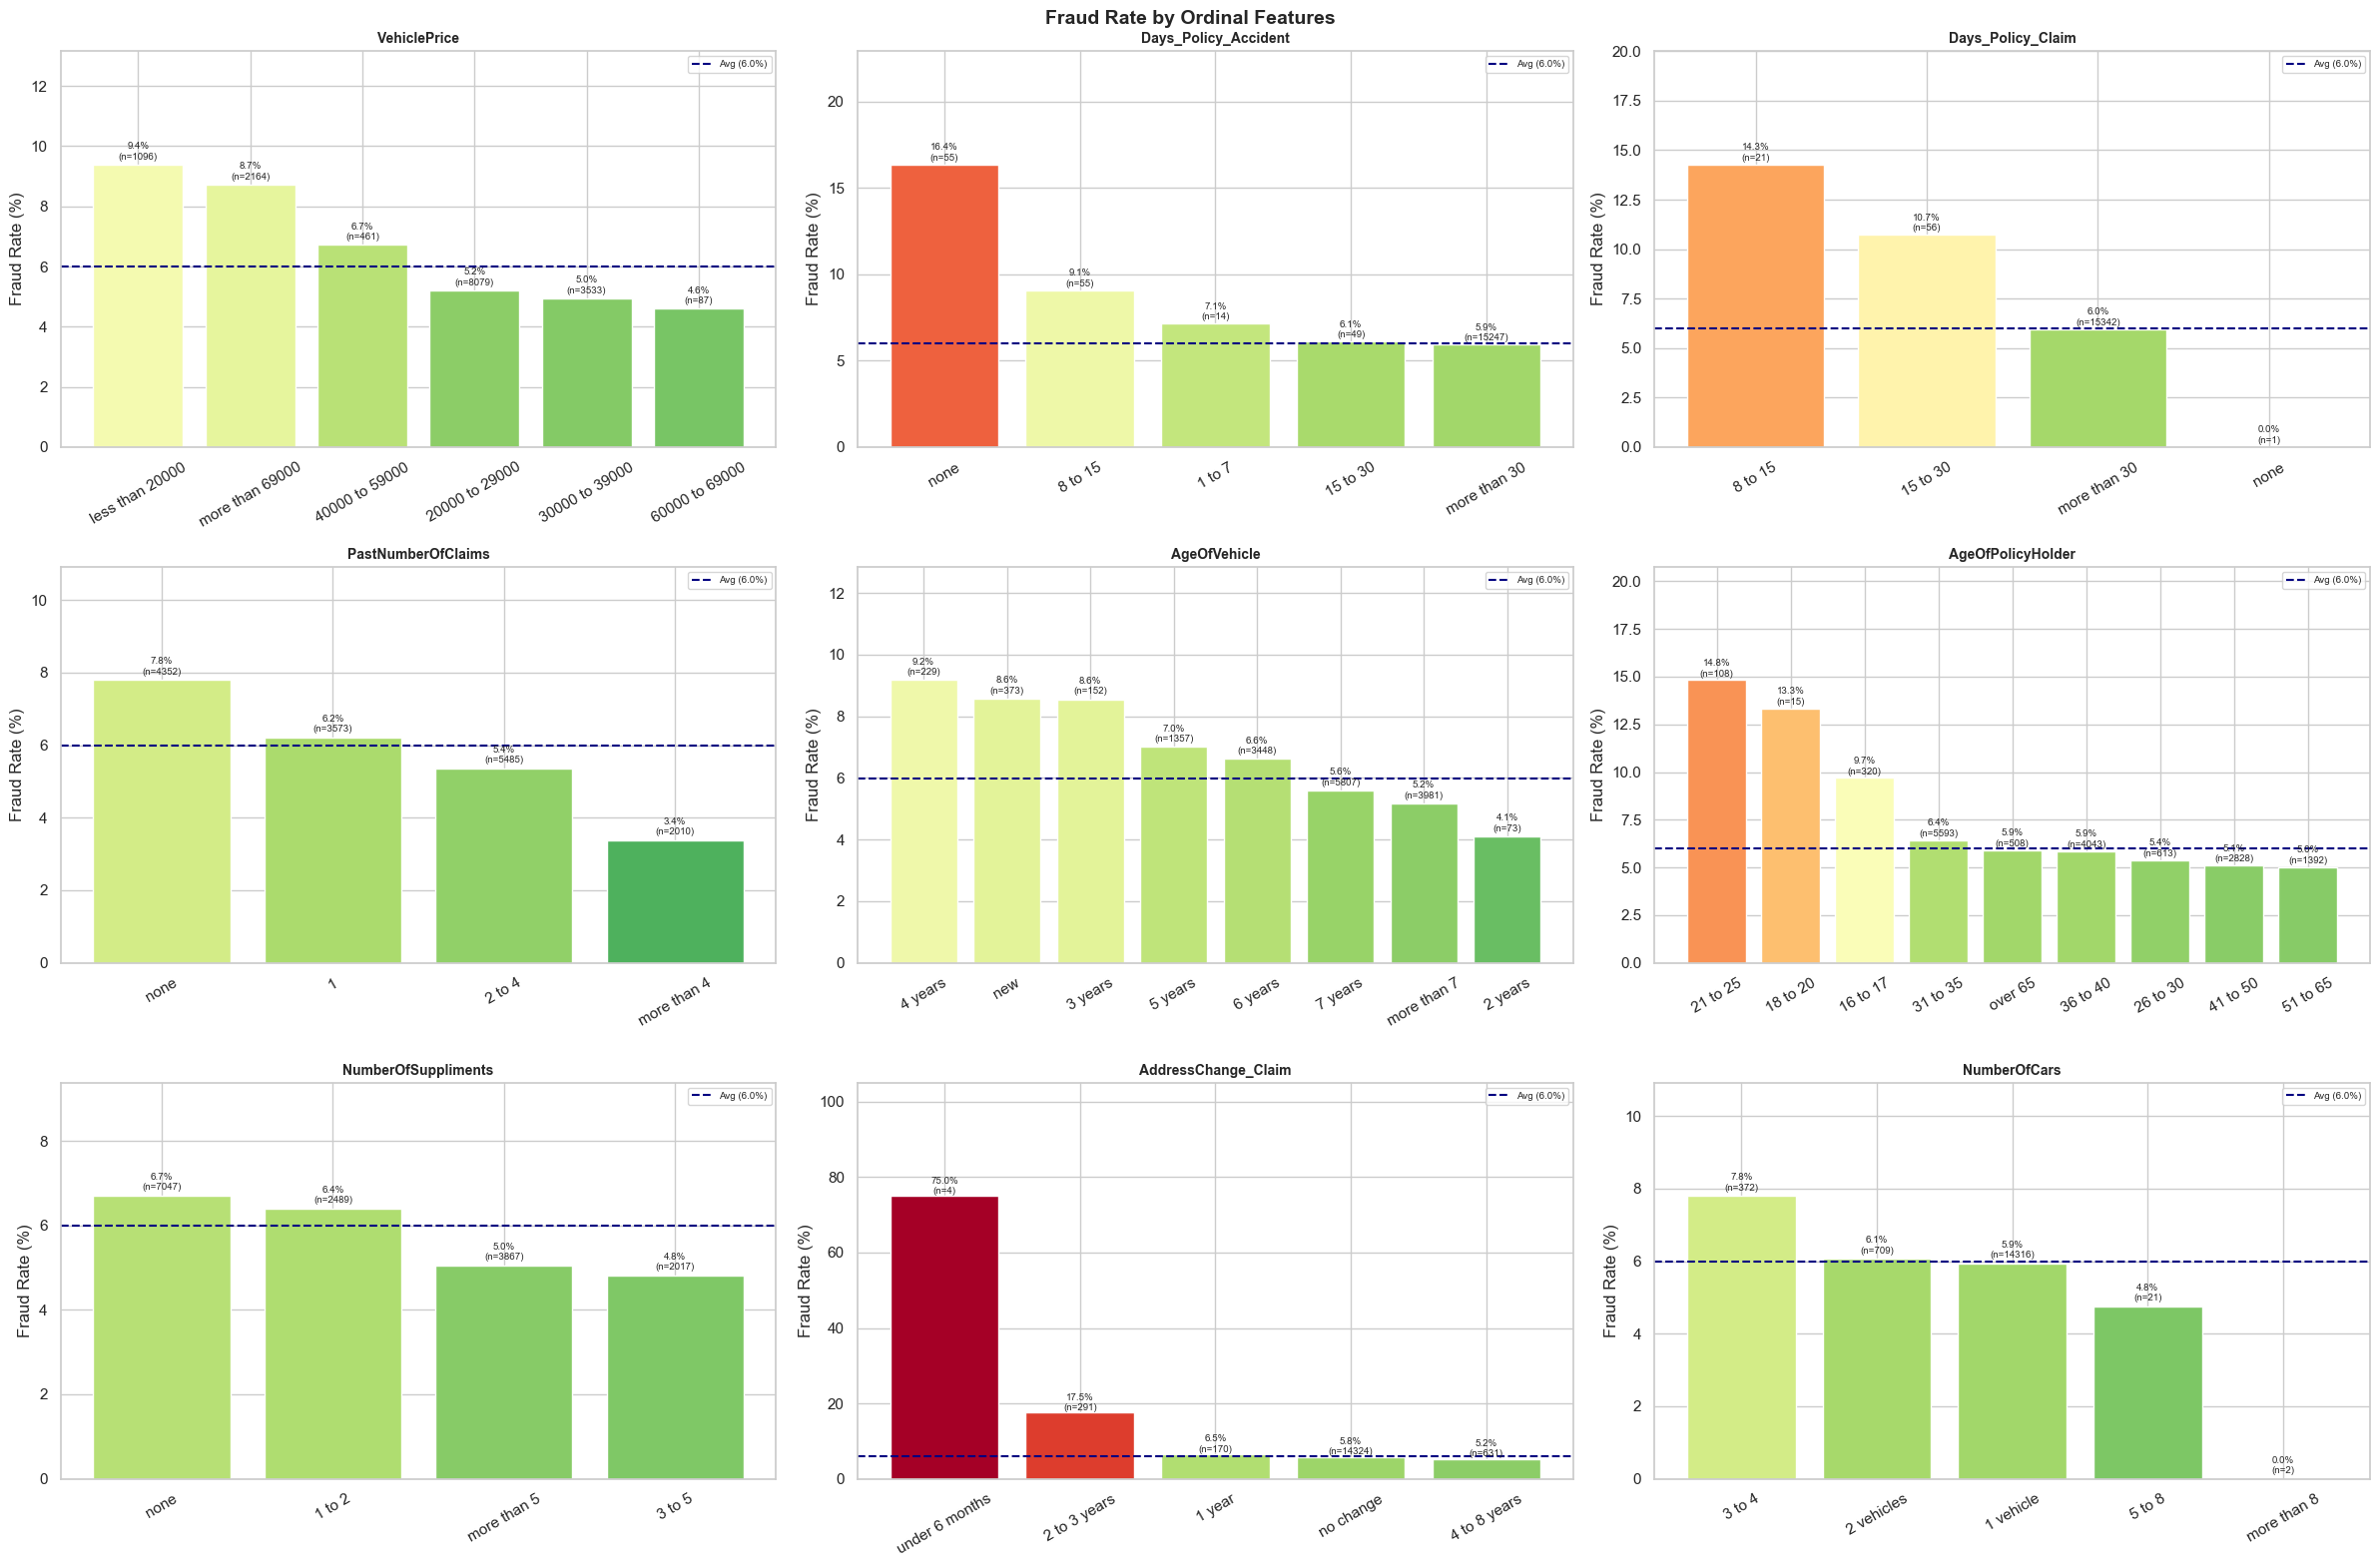

In [172]:
# Fraud rate for each ordinal column
fig, axes = plt.subplots(3, 3, figsize=(24, 16))
axes = axes.flatten()

for i, col in enumerate(ORDINAL_COLS):
    ax = axes[i]
    fraud_rate = df.groupby(col)['FraudFound_P'].mean().sort_values(ascending=False) * 100
    count = df.groupby(col)['FraudFound_P'].count().reindex(fraud_rate.index)
    bars = ax.bar(fraud_rate.index.astype(str), fraud_rate.values,
                  color=plt.cm.RdYlGn_r(fraud_rate.values / 20), edgecolor='white')
    for bar, val, cnt in zip(bars, fraud_rate.values, count.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%\n(n={cnt})', ha='center', va='bottom', fontsize=7)
    ax.axhline(y=overall_rate, color='navy', linestyle='--', linewidth=1.5,
               label=f'Avg ({overall_rate:.1f}%)')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_ylim(0, max(fraud_rate.values) * 1.4)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7)

plt.suptitle('Fraud Rate by Ordinal Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6 — Bivariate Analysis (Key Relationships)

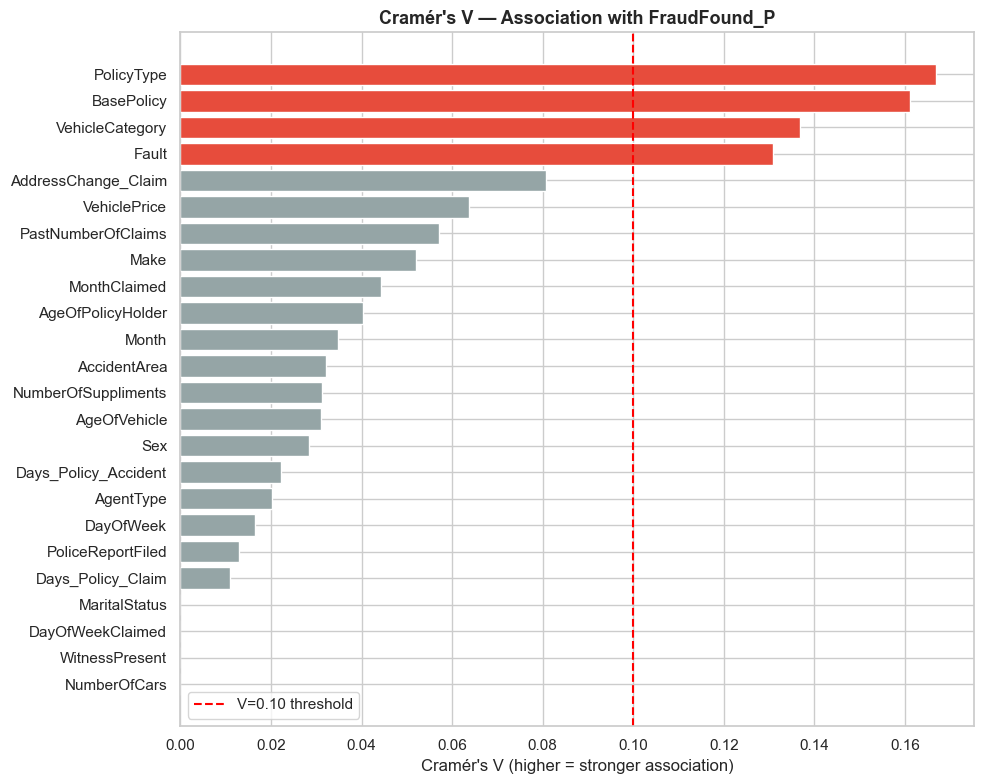


Top features by association:


,Feature,Cramers_V
9,PolicyType,0.1669
14,BasePolicy,0.1612
10,VehicleCategory,0.1369
8,Fault,0.1308
22,AddressChange_Claim,0.0808
15,VehiclePrice,0.0638
18,PastNumberOfClaims,0.0572
2,Make,0.0521
5,MonthClaimed,0.0443
20,AgeOfPolicyHolder,0.0403


In [173]:
# Cramér's V — association strength between each categorical and FraudFound_P
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    phi2corr = max(0, chi2/n - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0

ALL_CATS = NOMINAL_COLS + ORDINAL_COLS
target_str = df['FraudFound_P'].astype(str)

cv_results = []
for col in ALL_CATS:
    v = cramers_v(df[col].astype(str), target_str)
    cv_results.append({'Feature': col, 'Cramers_V': round(v, 4)})

cv_df = pd.DataFrame(cv_results).sort_values('Cramers_V', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v >= 0.1 else '#95a5a6' for v in cv_df['Cramers_V']]
ax.barh(cv_df['Feature'][::-1], cv_df['Cramers_V'][::-1], color=colors[::-1])
ax.axvline(x=0.1, color='red', linestyle='--', linewidth=1.5, label='V=0.10 threshold')
ax.set_title("Cramér's V — Association with FraudFound_P", fontsize=13, fontweight='bold')
ax.set_xlabel("Cramér's V (higher = stronger association)")
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop features by association:')
display(cv_df.head(15))

---
## Section 7 — Correlation Analysis

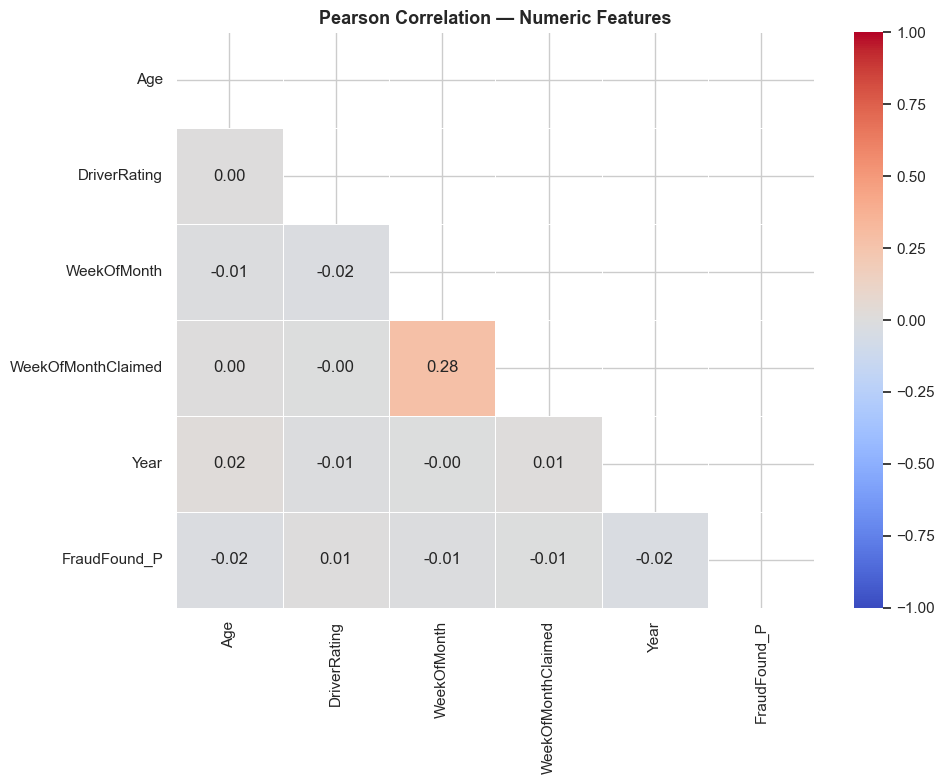

In [174]:
# Pearson correlation among numeric features + target
corr_cols = NUMERIC_COLS + ['FraudFound_P']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Pearson Correlation — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [175]:
# Point-biserial for all numeric vs FraudFound_P
print('Point-biserial correlation with FraudFound_P:')
print('-' * 50)
pb_results = []
for col in NUMERIC_COLS:
    corr, pval = pointbiserialr(df['FraudFound_P'], df[col])
    pb_results.append({'Feature': col, 'r': round(corr, 4), 'p': round(pval, 4)})
    sig = '✓' if pval < 0.05 else '✗'
    print(f'  {sig} {col:<25} r = {corr:+.4f}  (p={pval:.4f})')

Point-biserial correlation with FraudFound_P:
--------------------------------------------------
  ✓ Age                       r = -0.0226  (p=0.0051)
  ✗ DriverRating              r = +0.0073  (p=0.3669)
  ✗ WeekOfMonth               r = -0.0119  (p=0.1408)
  ✗ WeekOfMonthClaimed        r = -0.0058  (p=0.4744)
  ✓ Year                      r = -0.0248  (p=0.0021)


---
## Section 8 — EDA Summary & Final Feature List

In [177]:
print('=' * 65)
print('  EDA SUMMARY — Vehicle Insurance Fraud Detection')
print('=' * 65)
print(f"""
DATASET
  Rows      : {len(df):,}
  Columns   : {df.shape[1]}
  Target    : FraudFound_P (0/1)
  Fraud rate: {df['FraudFound_P'].mean()*100:.1f}%
  Imbalance : {label_counts[0]/label_counts[1]:.1f} : 1  → SMOTE required
  Missing   : 0
""")

print('FINAL FEATURE SET')
print('-' * 65)

features = {
    'Numeric (StandardScaler)': ['Age', 'DriverRating',
                                  'WeekOfMonth', 'WeekOfMonthClaimed', 'Year'],
    'Ordinal (OrdinalEncoder)': ['Deductible', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim',
                                  'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
                                  'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars'],
    'Nominal (OHE)':            ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
                                  'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
                                  'VehicleCategory', 'PoliceReportFiled', 'WitnessPresent',
                                  'AgentType', 'BasePolicy'],
    'DROP':                     ['PolicyNumber (dropped)', 'RepNumber (dropped)']
}

for group, cols in features.items():
    print(f'  [{group}]')
    for c in cols:
        print(f'    • {c}')

print()
print('MODELING PLAN')
print('-' * 65)
print('  Split       : 70% train / 15% val / 15% test (stratified)')
print('  Imbalance   : SMOTE on train only')
print('  Models      : Logistic Regression (baseline)')
print('                Isolation Forest → anomaly_score → extra feature')
print('                XGBoost')
print('                LightGBM')
print('  Metric      : AUC-PR (primary) + AUC-ROC + F1')
print('  Threshold   : Tuned on val set → 3-class output')
print('=' * 65)

  EDA SUMMARY — Vehicle Insurance Fraud Detection

DATASET
  Rows      : 15,420
  Columns   : 31
  Target    : FraudFound_P (0/1)
  Fraud rate: 6.0%
  Imbalance : 15.7 : 1  → SMOTE required
  Missing   : 0

FINAL FEATURE SET
-----------------------------------------------------------------
  [Numeric (StandardScaler)]
    • Age
    • DriverRating
    • WeekOfMonth
    • WeekOfMonthClaimed
    • Year
  [Ordinal (OrdinalEncoder)]
    • Deductible
    • VehiclePrice
    • Days_Policy_Accident
    • Days_Policy_Claim
    • PastNumberOfClaims
    • AgeOfVehicle
    • AgeOfPolicyHolder
    • NumberOfSuppliments
    • AddressChange_Claim
    • NumberOfCars
  [Nominal (OHE)]
    • Month
    • DayOfWeek
    • Make
    • AccidentArea
    • DayOfWeekClaimed
    • MonthClaimed
    • Sex
    • MaritalStatus
    • Fault
    • PolicyType
    • VehicleCategory
    • PoliceReportFiled
    • WitnessPresent
    • AgentType
    • BasePolicy
  [DROP]
    • PolicyNumber (dropped)
    • RepNumber (dropped)



---
## Section 9 — Preprocessing Pipeline

In [178]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

df_clean = df.copy()

# Define ordinal orders
ORDINAL_ORDERS = {
    'Deductible':            [[300, 400, 500, 700]],
    'VehiclePrice':          [['less than 20000', '20000 to 29000', '30000 to 39000',
                                '40000 to 59000', '60000 to 69000', 'more than 69000']],
    'Days_Policy_Accident':  [['none', '1 to 7', '8 to 15', '15 to 30', 'more than 30']],
    'Days_Policy_Claim':     [['none', '8 to 15', '15 to 30', 'more than 30']],
    'PastNumberOfClaims':    [['none', '1', '2 to 4', 'more than 4']],
    'AgeOfVehicle':          [['new', '2 years', '3 years', '4 years', '5 years',
                                '6 years', '7 years', 'more than 7']],
    'AgeOfPolicyHolder':     [['16 to 17', '18 to 20', '21 to 25', '26 to 30', '31 to 35',
                                '36 to 40', '41 to 50', '51 to 65', 'over 65']],
    'NumberOfSuppliments':   [['none', '1 to 2', '3 to 5', 'more than 5']],
    'AddressChange_Claim':   [['no change', 'under 6 months', '1 year',
                                '2 to 3 years', '4 to 8 years']],
    'NumberOfCars':          [['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']]
}

print('Ordinal orders defined for', len(ORDINAL_ORDERS), 'columns.')

Ordinal orders defined for 10 columns.


In [179]:
# Verify ordinal values match actual data (catch any mismatches)
print('Checking ordinal value coverage:')
for col, order in ORDINAL_ORDERS.items():
    actual = set(df_clean[col].unique())
    defined = set(order[0])
    missing = actual - defined
    if missing:
        print(f'  ⚠ {col}: values in data NOT in order list: {missing}')
    else:
        print(f'  ✓ {col}: all values covered')

Checking ordinal value coverage:
  ✓ Deductible: all values covered
  ✓ VehiclePrice: all values covered
  ✓ Days_Policy_Accident: all values covered
  ✓ Days_Policy_Claim: all values covered
  ✓ PastNumberOfClaims: all values covered
  ✓ AgeOfVehicle: all values covered
  ✓ AgeOfPolicyHolder: all values covered
  ✓ NumberOfSuppliments: all values covered
  ✓ AddressChange_Claim: all values covered
  ✓ NumberOfCars: all values covered


In [180]:
# Apply Ordinal Encoding
ordinal_cols = list(ORDINAL_ORDERS.keys())
ordinal_categories = [ORDINAL_ORDERS[col][0] for col in ordinal_cols]

ord_encoder = OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1)
df_clean[ordinal_cols] = ord_encoder.fit_transform(df_clean[ordinal_cols])

print('Ordinal encoding applied.')
print('Sample encoded values for PastNumberOfClaims:')
print(df_clean['PastNumberOfClaims'].value_counts().sort_index())

Ordinal encoding applied.
Sample encoded values for PastNumberOfClaims:
PastNumberOfClaims
0.0    4352
1.0    3573
2.0    5485
3.0    2010
Name: count, dtype: int64


In [181]:
# Apply One-Hot Encoding to nominal columns
NOMINAL_COLS_FINAL = ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
                       'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
                       'VehicleCategory', 'PoliceReportFiled', 'WitnessPresent',
                       'AgentType', 'BasePolicy']

df_encoded = pd.get_dummies(df_clean[NOMINAL_COLS_FINAL], drop_first=True, dtype=int)
print(f'OHE features created: {df_encoded.shape[1]} columns')

OHE features created: 75 columns


In [182]:
# Build final feature matrix
NUMERIC_FEATURES = ['Age', 'DriverRating', 'WeekOfMonth', 'WeekOfMonthClaimed', 'Year']
# Deductible is in ordinal_cols (only 4 discrete values)
TARGET = 'FraudFound_P'

X = pd.concat([
    df_clean[NUMERIC_FEATURES + ordinal_cols].reset_index(drop=True),
    df_encoded.reset_index(drop=True)
], axis=1)

y = df_clean[TARGET].reset_index(drop=True)

print(f'Final feature matrix: {X.shape}')
print(f'Target distribution : {y.value_counts().to_dict()}')

Final feature matrix: (15420, 90)
Target distribution : {0: 14497, 1: 923}


---
## Section 10 — Train / Val / Test Split + SMOTE

In [184]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 70% train | 15% val | 15% test — stratified
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {X_train.shape[0]:,} rows | Fraud: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Val   : {X_val.shape[0]:,} rows | Fraud: {y_val.sum()} ({y_val.mean()*100:.1f}%)')
print(f'Test  : {X_test.shape[0]:,} rows | Fraud: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train : 10,794 rows | Fraud: 646 (6.0%)
Val   : 2,313 rows | Fraud: 139 (6.0%)
Test  : 2,313 rows | Fraud: 138 (6.0%)


In [185]:
# Scale numeric features — fit on train only
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

SCALE_COLS = NUMERIC_FEATURES
X_train_scaled[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_val_scaled[SCALE_COLS]   = scaler.transform(X_val[SCALE_COLS])
X_test_scaled[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

print('StandardScaler fitted on train, applied to val/test.')

StandardScaler fitted on train, applied to val/test.


In [186]:
# SMOTE — apply on TRAIN only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After  SMOTE: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')

Before SMOTE: {0: 10148, 1: 646}
After  SMOTE: {np.int64(0): np.int64(10148), np.int64(1): np.int64(10148)}


---
## Section 11 — Baseline: Logistic Regression

In [191]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, confusion_matrix,
                              precision_recall_curve, f1_score)

def evaluate_model(name, y_true, y_proba, threshold=0.5):
    preds = (y_proba >= threshold).astype(int)
    auc_roc = roc_auc_score(y_true, y_proba)
    auc_pr  = average_precision_score(y_true, y_proba)

    print(f'\n=== {name} (threshold={threshold}) ===')
    print(f'  AUC-ROC : {auc_roc:.4f}')
    print(f'  AUC-PR  : {auc_pr:.4f}  ← primary metric')
    print()
    print(classification_report(y_true, preds, target_names=['Not Fraud', 'Fraud']))

    cm = confusion_matrix(y_true, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'])
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'AUC-ROC': round(auc_roc, 4), 'AUC-PR': round(auc_pr, 4)}

print('evaluate_model() function defined.')

evaluate_model() function defined.



=== Logistic Regression (threshold=0.5) ===
  AUC-ROC : 0.7674
  AUC-PR  : 0.1446  ← primary metric

              precision    recall  f1-score   support

   Not Fraud       0.95      0.94      0.94      2174
       Fraud       0.15      0.16      0.16       139

    accuracy                           0.90      2313
   macro avg       0.55      0.55      0.55      2313
weighted avg       0.90      0.90      0.90      2313



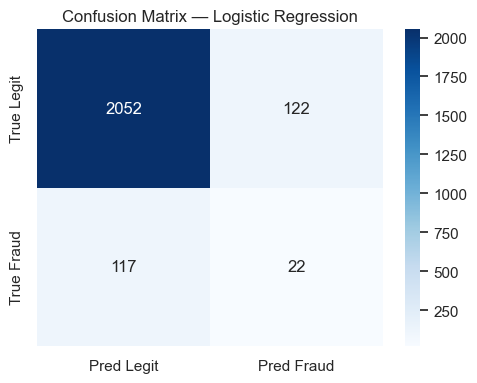

In [192]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

lr_proba = lr.predict_proba(X_val_scaled)[:, 1]
lr_result = evaluate_model('Logistic Regression', y_val, lr_proba)

---
## Section 12 — Isolation Forest (Anomaly Score Feature)

In [193]:
from sklearn.ensemble import IsolationForest

# Fit on training data only (before SMOTE — real distribution)
iso_forest = IsolationForest(n_estimators=100, contamination=0.06, random_state=42)
iso_forest.fit(X_train_scaled)

# Negate score: higher = more anomalous
train_anomaly = -iso_forest.score_samples(X_train_sm)
val_anomaly   = -iso_forest.score_samples(X_val_scaled)
test_anomaly  = -iso_forest.score_samples(X_test_scaled)

print('Isolation Forest fitted.')
print(f'Anomaly score range (val): {val_anomaly.min():.4f} → {val_anomaly.max():.4f}')

Isolation Forest fitted.
Anomaly score range (val): 0.3667 → 0.5472


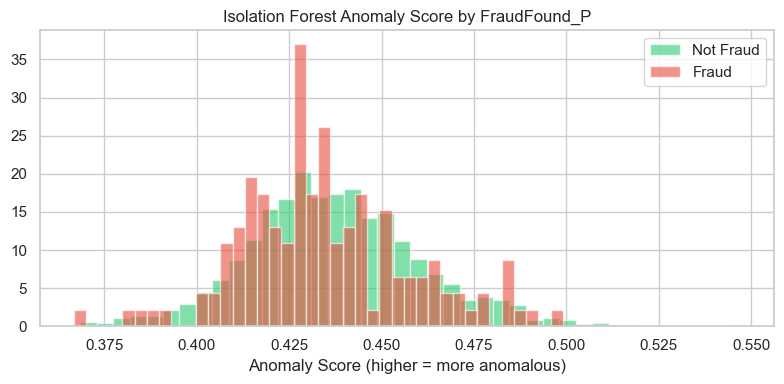

Anomaly score vs FraudFound_P: r = -0.0292  (p = 0.1605)


In [194]:
# Check if anomaly score separates fraud vs legitimate
anomaly_check = pd.DataFrame({'anomaly_score': val_anomaly, 'FraudFound_P': y_val.values})

fig, ax = plt.subplots(figsize=(8, 4))
for label_val, color, name in [(0, '#2ecc71', 'Not Fraud'), (1, '#e74c3c', 'Fraud')]:
    ax.hist(anomaly_check[anomaly_check['FraudFound_P']==label_val]['anomaly_score'],
            bins=40, alpha=0.6, color=color, label=name, density=True)
ax.set_title('Isolation Forest Anomaly Score by FraudFound_P')
ax.set_xlabel('Anomaly Score (higher = more anomalous)')
ax.legend()
plt.tight_layout()
plt.show()

corr, pval = pointbiserialr(anomaly_check['FraudFound_P'], anomaly_check['anomaly_score'])
print(f'Anomaly score vs FraudFound_P: r = {corr:.4f}  (p = {pval:.4f})')

In [195]:
# Add anomaly score as a feature to all splits
X_train_xgb = np.column_stack([X_train_sm, train_anomaly])
X_val_xgb   = np.column_stack([X_val_scaled, val_anomaly])
X_test_xgb  = np.column_stack([X_test_scaled, test_anomaly])

feature_names_xgb = list(X_train_scaled.columns) + ['anomaly_score']

print(f'Feature matrix with anomaly score: {X_train_xgb.shape}')

Feature matrix with anomaly score: (20296, 91)


---
## Section 13 — XGBoost


=== XGBoost (threshold=0.5) ===
  AUC-ROC : 0.8485
  AUC-PR  : 0.2297  ← primary metric

              precision    recall  f1-score   support

   Not Fraud       0.94      0.99      0.97      2174
       Fraud       0.32      0.09      0.14       139

    accuracy                           0.93      2313
   macro avg       0.63      0.54      0.55      2313
weighted avg       0.91      0.93      0.92      2313



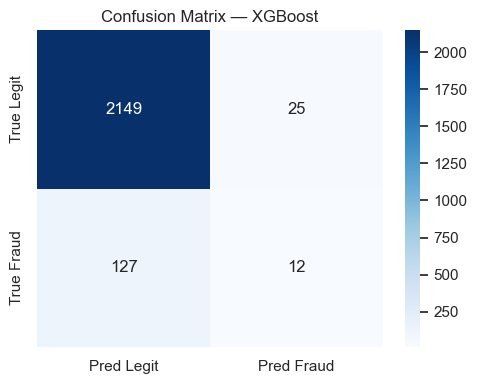

In [197]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)

xgb.fit(X_train_xgb, y_train_sm,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False)

xgb_proba  = xgb.predict_proba(X_val_xgb)[:, 1]
xgb_result = evaluate_model('XGBoost', y_val, xgb_proba)

---
## Section 14 — LightGBM


=== LightGBM (threshold=0.5) ===
  AUC-ROC : 0.8495
  AUC-PR  : 0.2408  ← primary metric

              precision    recall  f1-score   support

   Not Fraud       0.94      0.99      0.97      2174
       Fraud       0.32      0.09      0.14       139

    accuracy                           0.93      2313
   macro avg       0.63      0.54      0.55      2313
weighted avg       0.91      0.93      0.92      2313



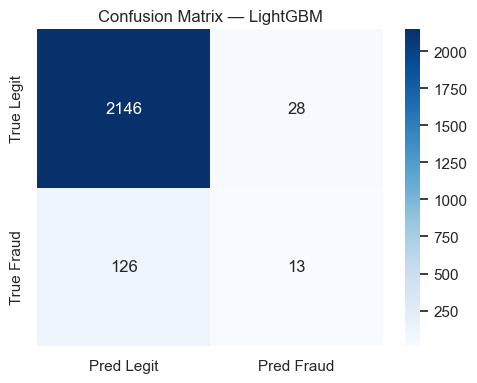

In [201]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train_xgb, y_train_sm,
         eval_set=[(X_val_xgb, y_val)])

lgbm_proba  = lgbm.predict_proba(X_val_xgb)[:, 1]
lgbm_result = evaluate_model('LightGBM', y_val, lgbm_proba)

---
## Section 15 — Model Comparison

In [202]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'AUC-ROC': lr_result['AUC-ROC'],   'AUC-PR': lr_result['AUC-PR']},
    {'Model': 'XGBoost',             'AUC-ROC': xgb_result['AUC-ROC'],  'AUC-PR': xgb_result['AUC-PR']},
    {'Model': 'LightGBM',            'AUC-ROC': lgbm_result['AUC-ROC'], 'AUC-PR': lgbm_result['AUC-PR']},
]).set_index('Model').sort_values('AUC-PR', ascending=False)

print('Model Comparison (val set):')
display(results.style.background_gradient(cmap='Greens'))

best_model_name = results['AUC-PR'].idxmax()
print(f'\nBest model by AUC-PR: {best_model_name}')

Model Comparison (val set):


,AUC-ROC,AUC-PR
Model,,
LightGBM,0.849500,0.240800
XGBoost,0.848500,0.229700
Logistic Regression,0.767400,0.144600



Best model by AUC-PR: LightGBM


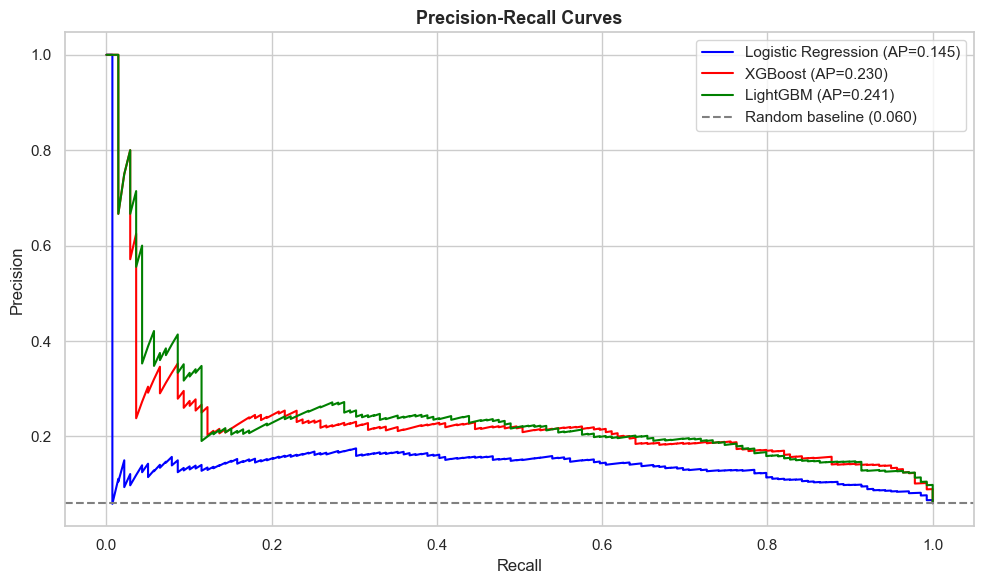

In [203]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(10, 6))

for proba, name, color in [
    (lr_proba,   'Logistic Regression', 'blue'),
    (xgb_proba,  'XGBoost',             'red'),
    (lgbm_proba, 'LightGBM',            'green')
]:
    precision, recall, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    ax.plot(recall, precision, color=color, label=f'{name} (AP={ap:.3f})')

ax.axhline(y=y_val.mean(), color='gray', linestyle='--',
           label=f'Random baseline ({y_val.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 16 — Threshold Tuning

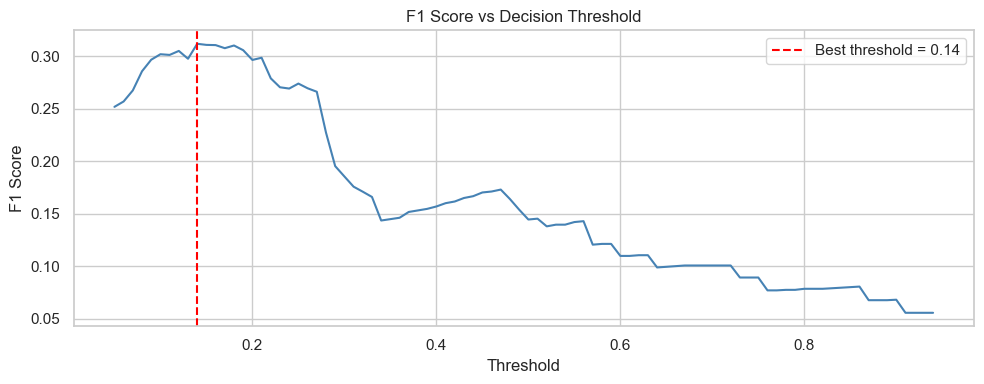

Optimal threshold: 0.14


In [206]:
# Select best model based on Section 15 results
# Update this line if LightGBM wins
best_model  = xgb if best_model_name == 'XGBoost' else lgbm
val_proba   = xgb_proba if best_model_name == 'XGBoost' else lgbm_proba

# Find optimal threshold by maximising F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, color='steelblue')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best threshold = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Optimal threshold: {best_thresh:.2f}')

In [208]:
# 3-class decision thresholds
LOW_THRESH  = round(max(best_thresh - 0.15, 0.05), 2)
HIGH_THRESH = round(min(best_thresh + 0.15, 0.90), 2)

def classify_3way(proba, low=LOW_THRESH, high=HIGH_THRESH):
    if proba < low:
        return 'APPROVED'
    elif proba < high:
        return 'HUMAN_REVIEW'
    else:
        return 'REJECTED'

val_decisions = pd.Series(val_proba).apply(classify_3way)
decision_df   = pd.DataFrame({'decision': val_decisions.values, 'true_label': y_val.values})

print(f'Thresholds: low={LOW_THRESH}, high={HIGH_THRESH}')
print('\nDecision distribution (val set):')
print(val_decisions.value_counts())
print('\nFraud rate per bucket:')
print((decision_df.groupby('decision')['true_label'].mean() * 100).round(2))

Thresholds: low=0.05, high=0.29

Decision distribution (val set):
APPROVED        1475
HUMAN_REVIEW     721
REJECTED         117
Name: count, dtype: int64

Fraud rate per bucket:
decision
APPROVED         1.08
HUMAN_REVIEW    13.59
REJECTED        21.37
Name: true_label, dtype: float64


---
## Section 17 — SHAP Explainability

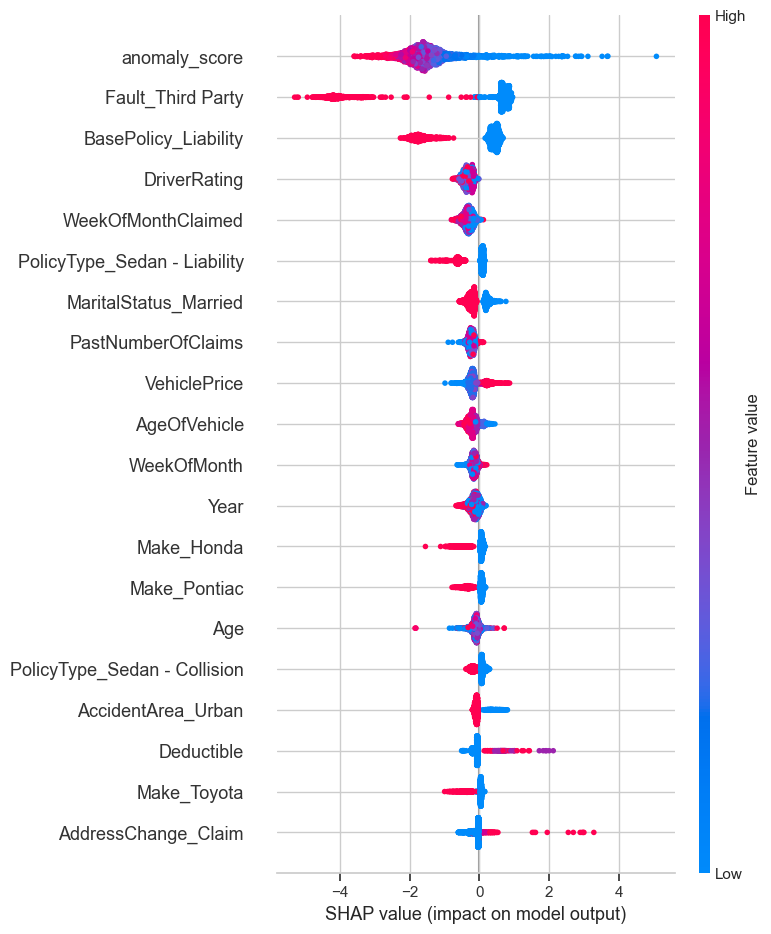

In [211]:
import shap

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_xgb)

shap.summary_plot(shap_values, X_val_xgb,
                  feature_names=feature_names_xgb,
                  max_display=20, show=True)

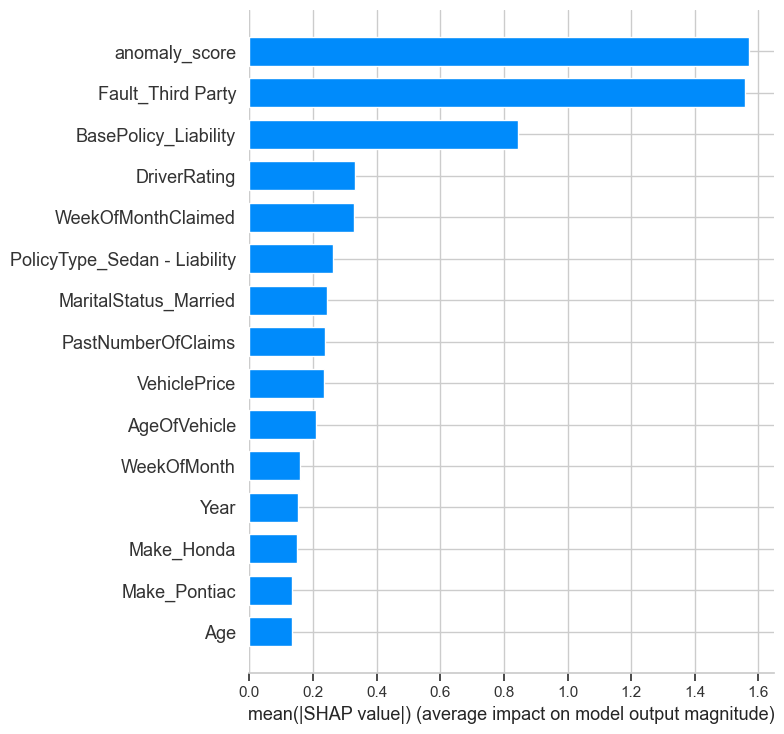


Top 15 Features by Mean Absolute SHAP Value:
--------------------------------------------------
   1. anomaly_score                       1.5702  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. Fault_Third Party                   1.5580  █████████████████

In [212]:
# Top 15 features by mean absolute SHAP value
shap.summary_plot(shap_values, X_val_xgb,
                  feature_names=feature_names_xgb,
                  plot_type='bar', max_display=15, show=True)

# Numerical summary of top 15 features
shap_importance = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(15).reset_index(drop=True)

shap_importance.index += 1  # rank from 1
shap_importance['Mean_SHAP'] = shap_importance['Mean_SHAP'].round(4)

print('\nTop 15 Features by Mean Absolute SHAP Value:')
print('-' * 50)
for i, row in shap_importance.iterrows():
    bar = '█' * int(row['Mean_SHAP'] * 500)
    print(f'  {i:>2}. {row["Feature"]:<35} {row["Mean_SHAP"]:.4f}  {bar}')

Borderline claim index : 1
Fraud probability      : 0.1647
Decision               : HUMAN_REVIEW
True label             : 1


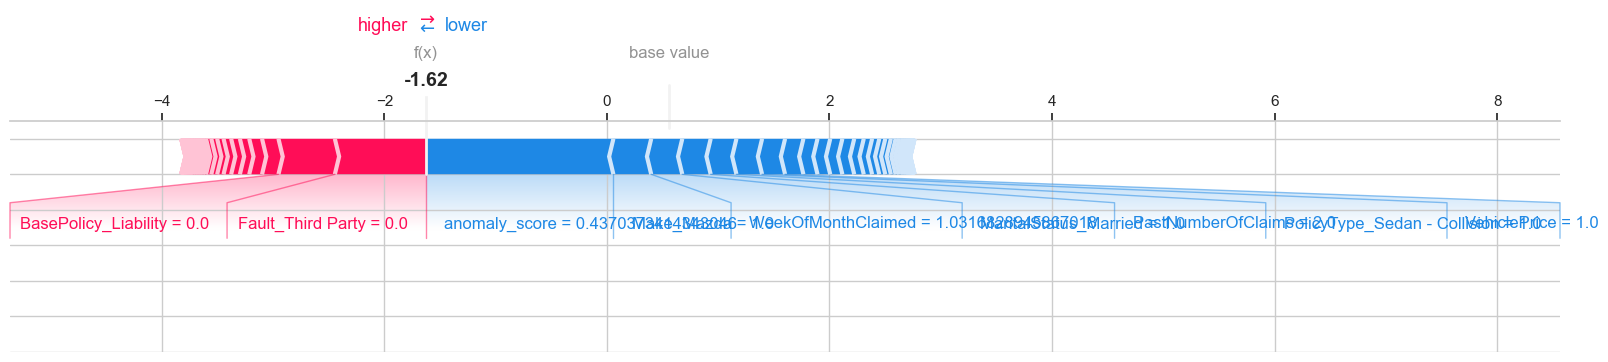

In [213]:
# Single claim explanation — borderline case
borderline_idx = np.where((val_proba >= LOW_THRESH) & (val_proba < HIGH_THRESH))[0]

if len(borderline_idx) > 0:
    idx = borderline_idx[0]
    print(f'Borderline claim index : {idx}')
    print(f'Fraud probability      : {val_proba[idx]:.4f}')
    print(f'Decision               : {classify_3way(val_proba[idx])}')
    print(f'True label             : {y_val.values[idx]}')
    shap.force_plot(explainer.expected_value, shap_values[idx],
                    X_val_xgb[idx], feature_names=feature_names_xgb, matplotlib=True)

---
## Section 18 — Final Evaluation on Test Set

=== FINAL TEST SET RESULTS ===
  AUC-ROC : 0.8201
  AUC-PR  : 0.2161

              precision    recall  f1-score   support

   Not Fraud       0.96      0.87      0.92      2175
       Fraud       0.20      0.50      0.28       138

    accuracy                           0.85      2313
   macro avg       0.58      0.69      0.60      2313
weighted avg       0.92      0.85      0.88      2313



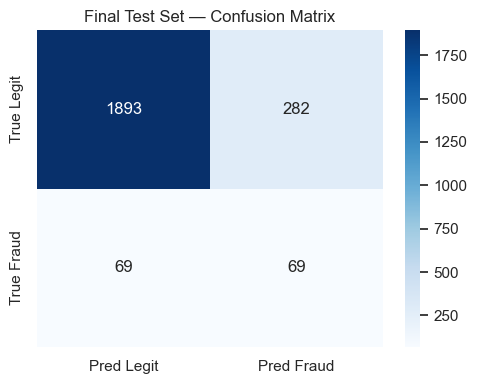

In [214]:
test_proba = best_model.predict_proba(X_test_xgb)[:, 1]
test_preds = (test_proba >= best_thresh).astype(int)

test_auc_roc = roc_auc_score(y_test, test_proba)
test_auc_pr  = average_precision_score(y_test, test_proba)

print('=== FINAL TEST SET RESULTS ===')
print(f'  AUC-ROC : {test_auc_roc:.4f}')
print(f'  AUC-PR  : {test_auc_pr:.4f}')
print()
print(classification_report(y_test, test_preds, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['True Legit', 'True Fraud'])
ax.set_title('Final Test Set — Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Section 19 — Save Models & Artifacts

In [215]:
import joblib
import json
import os

MODELS_DIR = r'C:\Users\RadheRadhe\Desktop\Self project\DS\project work\models'
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(best_model,   os.path.join(MODELS_DIR, 'fraud_model.pkl'))
joblib.dump(iso_forest,   os.path.join(MODELS_DIR, 'isolation_forest.pkl'))
joblib.dump(scaler,       os.path.join(MODELS_DIR, 'scaler.pkl'))
joblib.dump(ord_encoder,  os.path.join(MODELS_DIR, 'ordinal_encoder.pkl'))

# Save feature names and thresholds
config = {
    'low_threshold'    : LOW_THRESH,
    'high_threshold'   : HIGH_THRESH,
    'binary_threshold' : float(best_thresh),
    'best_model'       : best_model_name,
    'numeric_features' : NUMERIC_FEATURES,
    'ordinal_cols'     : ordinal_cols,
    'nominal_cols'     : NOMINAL_COLS_FINAL,
    'feature_names_xgb': feature_names_xgb
}
with open(os.path.join(MODELS_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print('Saved artifacts:')
for fname in os.listdir(MODELS_DIR):
    fpath = os.path.join(MODELS_DIR, fname)
    print(f'  {fname:<35} ({os.path.getsize(fpath):,} bytes)')

Saved artifacts:
  config.json                         (3,126 bytes)
  fraud_model.pkl                     (1,057,972 bytes)
  isolation_forest.pkl                (1,234,009 bytes)
  ordinal_encoder.pkl                 (3,925 bytes)
  scaler.pkl                          (991 bytes)
